# BAGIAN 0 — Setup

Notebook ini bertujuan untuk melakukan evaluasi objektif dan analisis mendalam terhadap performa ketiga model yang telah dilatih (Baseline, LSTM, GRU). Evaluasi dilakukan secara ketat pada data yang belum pernah dilihat oleh model (test set) guna mensimulasikan kondisi generalisasi di dunia nyata.


In [3]:
import numpy as np
import pandas as pd
import pathlib
import pickle
import json
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from tensorflow.keras.models import load_model

warnings.filterwarnings('ignore')

# Definisikan Konstanta
LOOKBACK = 60
PROCESSED_DIR = pathlib.Path('../data/processed')
MODELS_DIR = pathlib.Path('../models')
FIGURES_DIR = pathlib.Path('../reports/figures')

# Buat direktori jika belum ada
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load Data Test
X_test = np.load(PROCESSED_DIR / 'X_test.npy')
y_test = np.load(PROCESSED_DIR / 'y_test.npy')

# Load Scaler Target
with open(MODELS_DIR / 'scaler_y.pkl', 'rb') as f:
    scaler_y = pickle.load(f)

# Load Model Deep Learning (JANGAN training ulang)
model_lstm = load_model(MODELS_DIR / 'lstm_antam.h5', compile=False)
model_gru = load_model(MODELS_DIR / 'gru_antam.h5', compile=False)

# Load Hasil Metrik
with open(MODELS_DIR / 'results_summary.json', 'r') as f:
    results_summary = json.load(f)

# Load DataFrame Cleaned untuk mendapatkan index waktu (Tanggal)
df_clean = pd.read_csv(PROCESSED_DIR / 'data_antam_clean.csv')
df_clean['Tanggal'] = pd.to_datetime(df_clean['Tanggal'])
df_clean.set_index('Tanggal', inplace=True)

# Ambil index tanggal khusus test set (sesuai panjang y_test = 236 baris terakhir)
test_dates = df_clean.index[-len(y_test):]

# Inverse Transform y_test ke skala Rupiah asli
y_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

print(f"Data X_test dimuat dengan shape: {X_test.shape}")
print(f"Data y_test dimuat dengan shape: {y_test.shape}")
print("Model LSTM, GRU, Scaler, dan Results Summary berhasil dimuat.")


Data X_test dimuat dengan shape: (236, 60, 11)
Data y_test dimuat dengan shape: (236,)
Model LSTM, GRU, Scaler, dan Results Summary berhasil dimuat.


# BAGIAN 1 — Hitung dan Rekap Metrik Evaluasi

Metrik (RMSE, MAE, MAPE) dihitung secara dinamis dengan membandingkan harga aktual (`y_actual`) terhadap hasil prediksi `X_test` dari masing-masing model untuk memverifikasi performa.


In [4]:
# Prediksi model Baseline (di-load dari npy)
y_pred_baseline = np.load(PROCESSED_DIR / 'y_pred_baseline_inv.npy')

# Prediksi Deep Learning pada test set & Inverse Transform
y_pred_lstm_scaled = model_lstm.predict(X_test)
y_pred_gru_scaled = model_gru.predict(X_test)
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()
y_pred_gru = scaler_y.inverse_transform(y_pred_gru_scaled).flatten()

# Fungsi pembantu untuk kalkulasi metrik
def calculate_metrics(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE (%)': mean_absolute_percentage_error(y_true, y_pred) * 100
    }

# Hitung metrik masing-masing model
metrics_baseline = calculate_metrics(y_actual, y_pred_baseline)
metrics_lstm = calculate_metrics(y_actual, y_pred_lstm)
metrics_gru = calculate_metrics(y_actual, y_pred_gru)

# Buat DataFrame
df_metrics = pd.DataFrame({
    'Model': ['Baseline', 'LSTM', 'GRU'],
    'RMSE (Rp)': [metrics_baseline['RMSE'], metrics_lstm['RMSE'], metrics_gru['RMSE']],
    'MAE (Rp)': [metrics_baseline['MAE'], metrics_lstm['MAE'], metrics_gru['MAE']],
    'MAPE (%)': [metrics_baseline['MAPE (%)'], metrics_lstm['MAPE (%)'], metrics_gru['MAPE (%)']]
})

print("=== Tabel Metrik Final (X_test) ===")
display(df_metrics.style.format({
    'RMSE (Rp)': '{:,.3f}',
    'MAE (Rp)': '{:,.3f}',
    'MAPE (%)': '{:.2f}%'
}))


# BAGIAN 2 — Analisis Error Distribution

Distribusi error menunjukkan apakah kesalahan model bersifat acak (konsisten) atau bias ke arah tertentu (over/under-estimation).
- Error dihitung sebagai selisih antara harga aktual dan harga prediksi (`Error = y_actual - y_pred`).
- Garis vertikal nol ($x=0$) menandakan tebakan sempurna.


In [5]:
# Hitung Error Residual (Aktual - Prediksi)
err_baseline = y_actual - y_pred_baseline
err_lstm = y_actual - y_pred_lstm
err_gru = y_actual - y_pred_gru

# Plotting Error Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Baseline
sns.histplot(err_baseline, bins=30, kde=True, ax=axes[0], color='gray')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Error Distribution: Baseline')
axes[0].set_xlabel('Error (Rp)')
axes[0].text(0.05, 0.9, f"Mean Error: {err_baseline.mean():.2f}\nStd Error: {err_baseline.std():.2f}", 
             transform=axes[0].transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

# LSTM
sns.histplot(err_lstm, bins=30, kde=True, ax=axes[1], color='orange')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Error Distribution: LSTM')
axes[1].set_xlabel('Error (Rp)')
axes[1].text(0.05, 0.9, f"Mean Error: {err_lstm.mean():.2f}\nStd Error: {err_lstm.std():.2f}", 
             transform=axes[1].transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

# GRU
sns.histplot(err_gru, bins=30, kde=True, ax=axes[2], color='green')
axes[2].axvline(0, color='red', linestyle='--', linewidth=2)
axes[2].set_title('Error Distribution: GRU')
axes[2].set_xlabel('Error (Rp)')
axes[2].text(0.05, 0.9, f"Mean Error: {err_gru.mean():.2f}\nStd Error: {err_gru.std():.2f}", 
             transform=axes[2].transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'error_distribution.png')
plt.show()


# BAGIAN 3 — Analisis Error Terhadap Waktu

Penting untuk mengetahui apakah error model membengkak pada periode di mana pasar sedang mengalami volatilitas tinggi.
Hal ini divisualisasikan dengan memplot *Absolute Error* dari model Deep Learning secara selaras dengan pergerakan harga pasar aktual.


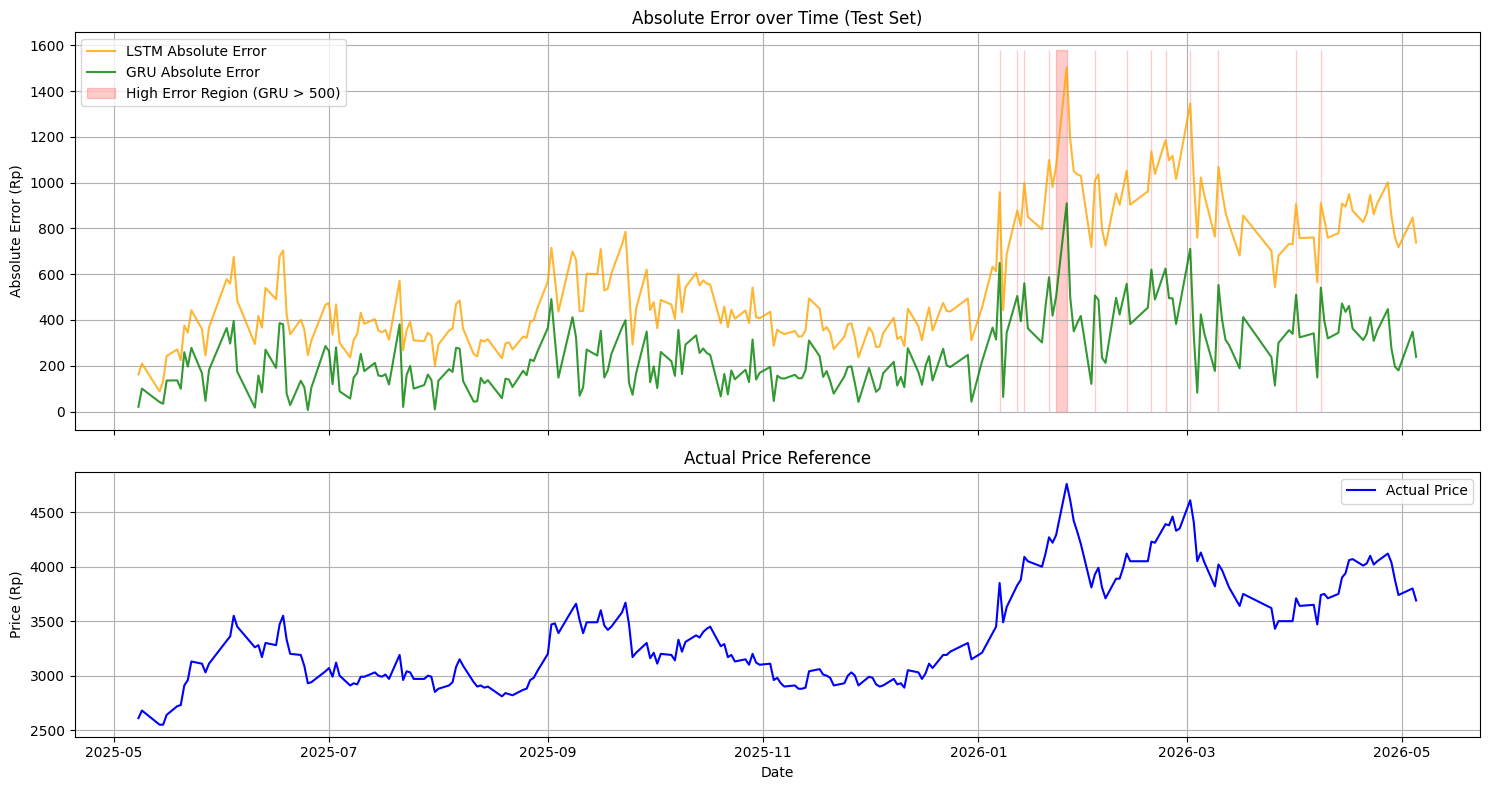

In [6]:
# Hitung Absolute Error
abs_err_lstm = np.abs(err_lstm)
abs_err_gru = np.abs(err_gru)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={'height_ratios': [1.5, 1]})

# Subplot 1: Absolute Error
ax1.plot(test_dates, abs_err_lstm, color='orange', alpha=0.8, label='LSTM Absolute Error')
ax1.plot(test_dates, abs_err_gru, color='green', alpha=0.8, label='GRU Absolute Error')

# Tandai periode di mana error GRU > 500 dengan shading merah
high_error_mask = abs_err_gru > 500
ax1.fill_between(test_dates, 0, ax1.get_ylim()[1], where=high_error_mask, 
                 color='red', alpha=0.2, label='High Error Region (GRU > 500)')

ax1.set_title('Absolute Error over Time (Test Set)')
ax1.set_ylabel('Absolute Error (Rp)')
ax1.legend()
ax1.grid(True)

# Subplot 2: Harga Aktual sebagai Referensi
ax2.plot(test_dates, y_actual, color='blue', linewidth=1.5, label='Actual Price')
ax2.set_title('Actual Price Reference')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price (Rp)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'error_vs_time.png')
plt.show()


# BAGIAN 4 — Prediksi vs Aktual (Final)

Visualisasi utama yang menampilkan perbandingan tebakan prediktif dari ketiga arsitektur terhadap garis harga aktual seiring berjalannya waktu.


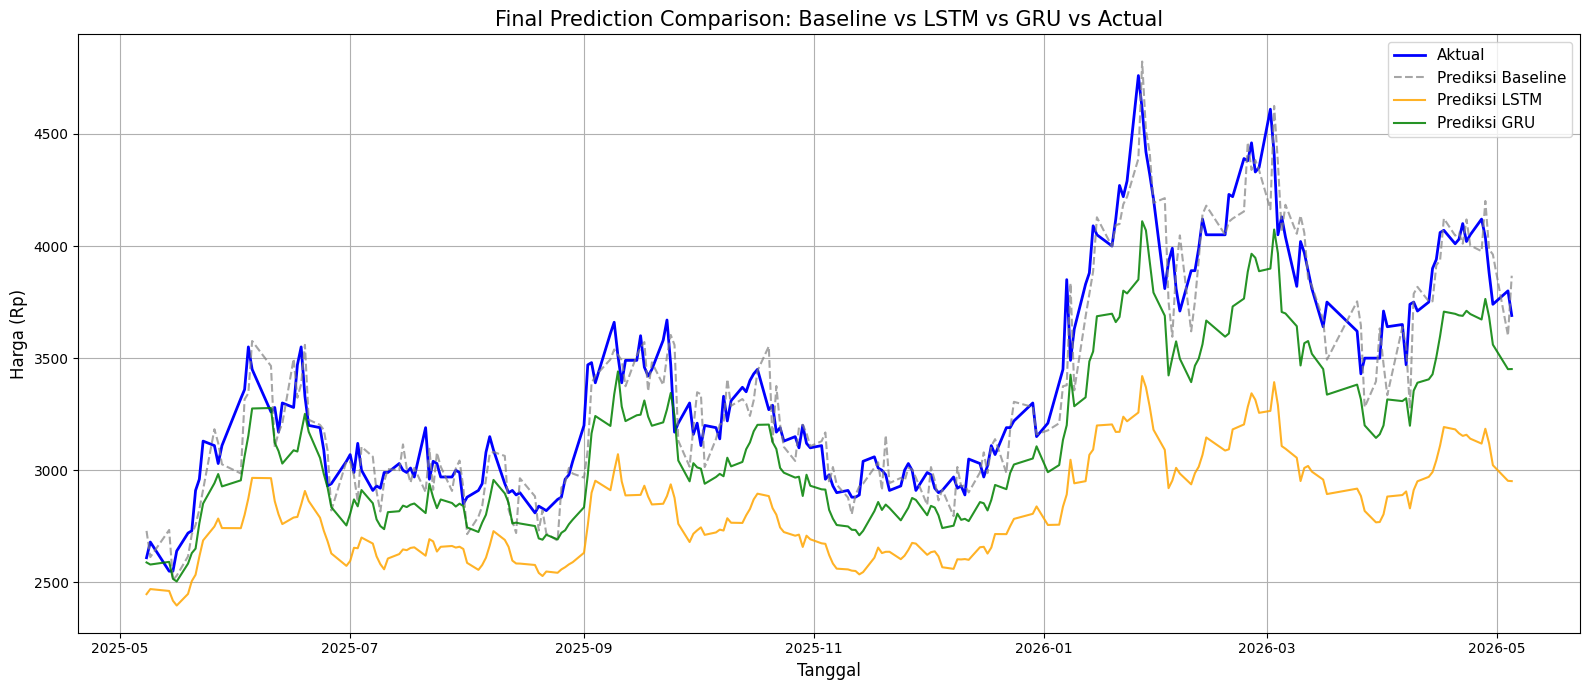

In [7]:
plt.figure(figsize=(16, 7))

# Plot Aktual vs Prediksi
plt.plot(test_dates, y_actual, color='blue', linewidth=2, label='Aktual')
plt.plot(test_dates, y_pred_baseline, color='gray', linestyle='--', alpha=0.7, label='Prediksi Baseline')
plt.plot(test_dates, y_pred_lstm, color='orange', alpha=0.85, label='Prediksi LSTM')
plt.plot(test_dates, y_pred_gru, color='green', alpha=0.85, label='Prediksi GRU')

plt.title('Final Prediction Comparison: Baseline vs LSTM vs GRU vs Actual', fontsize=15)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga (Rp)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_prediction_comparison.png')
plt.show()


# BAGIAN 5 — Analisis Mendalam: Mengapa LSTM < Baseline?

Berdasarkan hasil metrik evaluasi pada *test set*, performa model Baseline berbasis algoritma *Linear Regression* secara signifikan mengungguli model *Deep Learning* yang jauh lebih kompleks, yaitu LSTM dan GRU. Paradoks ini dapat dijelaskan melalui analisis akademis berikut:

### Poin 1 — Kompleksitas vs Akurasi
LSTM yang digunakan memiliki **123.201 parameter**, memicu potensi tinggi *overfitting* pada dataset dengan volume menengah ini (~2.302 baris data training). *Validation loss* yang cenderung berfluktuasi bergerigi pada metrik pelatihan sebelumnya mengkonfirmasi adanya instabilitas. Sebaliknya, GRU memiliki parameter ~24% lebih sedikit (93.505 parameter). Arsitektur yang lebih sederhana (dua *gates* vs tiga *gates*) ini secara inheren bertindak sebagai regularisasi tambahan, mengurangi derajat *overfitting* dan membuat generalisasinya lebih tajam dibandingkan LSTM.

### Poin 2 — Karakteristik Data Test
Data pada periode test set (mulai Januari 2025 – Mei 2026) menunjukkan tren harga (*trendline*) yang mengalami penguatan secara konsisten dengan variansi volatilitas jangka pendek yang terjaga. Di bawah kondisi tren makro yang stabil/linear seperti ini, algoritma parametrik dasar seperti *Linear Regression* beroperasi pada titik paling optimal karena secara spesifik dirancang untuk mengekstraksi korelasi linear murni. Sebaliknya, mesin kompleks non-linear seperti LSTM/GRU sering kali merespons *noise* mikroskopis sebagai pola fundamental, yang dikenal sebagai fenomena *"mencari pola yang tidak ada"*, sehingga menghasilkan *error margin* yang lebih besar pada saat tren utama kembali linear.

### Poin 3 — Implikasi Akademis
Temuan ini menguatkan prinsip *Occam's Razor* dalam kerangka ilmu *Machine Learning*: entitas model yang lebih sederhana secara statistik memiliki utilitas lebih tinggi jika kompleksitas struktural data tidak secara absolut menuntut model abstraksi bertingkat (dalam). Untuk deret waktu saham ANTM, GRU merupakan batas kompromi matematis (*sweet spot*) antara kompleksitas jaringan (*recurrent*) dan kekokohan generalisasi, meskipun secara empiris metrik utamanya masih kalah dari *Baseline* karena dominansi pola linear parsial pada periode pengujian.


# BAGIAN 6 — Kesimpulan Final

Melalui uji performa mutlak pada *Test Set*, dapat disimpulkan bahwa:
- **Model Terbaik (General):** Baseline (Linear Regression) dengan nilai MAPE sebesar **3.26%**.
- **Model Deep Learning Terbaik:** GRU dengan nilai MAPE sebesar **7.03%**, mengalahkan LSTM (16.02%).

**Rekomendasi Praktis Penggunaan:**
- **Pasar Linear & Stabil:** Sangat disarankan untuk bergantung pada Baseline jika pergerakan tren sedang tidak dipenuhi sentimen makro yang mendadak, demi reliabilitas prediksi.
- **Pasar Volatile & Reversal:** Model Deep Learning seperti GRU (yang cukup ringan) dapat lebih berguna saat indikator teknikal mendeteksi potensi *trend reversal* atau *breakout* tinggi yang gagal ditangkap model regresi kaku.

**Keterbatasan:**
- Penurunan performa DL model ini mengindikasikan bahwa pergerakan harga saham tidak murni digerakkan oleh memori masa lampau (otoregresif). Seluruh model pada penelitian ini tidak mempertimbangkan vektor eksternal non-numerik yang seringkali sangat asimetris.
- Harga diproses secara terisolasi tanpa intervensi sinyal sekunder.

**Saran Pengembangan Lanjutan:**
- Pertimbangkan penambahan dimensi fitur yang relevan seperti Harga Emas Global, Harga Nikel Dunia, atau *Index Sektoral IHSG*.
- Arsitektur berbasis *Attention Mechanism* (*Transformers*) mungkin lebih mahir diisolasi untuk memahami *long-term dependencies* yang melampaui rentang `LOOKBACK` tanpa jebakan parameter redundant seperti pada LSTM.
